In [1]:
import matplotlib.pyplot as plt
import numpy as np
import qutip as qt
from IPython.display import display, Math, Latex
from scipy.fft import fft, ifft
import scipy.special as sp
import scipy.optimize 
import matplotlib.ticker as ticker
import cmath

Gain and efficiency calculations based on "Boutin, Samuel, et al. "Effect of higher-order nonlinearities on amplification and squeezing in Josephson parametric amplifiers." Physical Review Applied 8.5 (2017): 054030."

Initial Parameters

In [2]:
Delta, w, kappa, drive, theta, phi, n_levels, step = 0, 0, 300e6*2*np.pi, 0.2, -np.pi/2, 0, 150, 30 
#no detuning w0 - wp/2, ws-wp/2, cavity decay rate, probe amplitude, drive phase, signal phase, n_levels, # of elements for drive sweep

Two-photon drive ($0\leq\lambda<\kappa/2$) sweep range

In [3]:
lam_range = np.linspace(0,1.98,step)*kappa/4

In [4]:
def jpa_params(
    F_JPA=np.pi/4,
    EC_J=85e5 * 2*np.pi,
    EJ=1900e9 * 2*np.pi,
):
    """
    Returns:
      ratio : |LAM/lam| for JPA 
      Kerr  : Kerr coefficient
      phi_zpf_JPA : included for convenience
    """
    phi_zpf_JPA = (2 * EC_J / EJ)**0.25
    ratio = phi_zpf_JPA**2 / 6.0
    Kerr = -EC_J * np.cos(F_JPA) / 2.0
    return ratio, Kerr, phi_zpf_JPA

In [5]:
def kfjpa_params(
    EC=48e5 * 2*np.pi,
    EL=1650e9 * 2*np.pi,
):
    """
    Returns:
      ratio : |LAM/lam| for Kerr-free JPA
      phi_zps : included for convenience
    """
    phi_zps = (2 * EC / EL)**0.25
    ratio = phi_zps**2 / 6.0
    return ratio, phi_zps

In [6]:
def _quadratures_from_a(a_c):
    """Return (X, P) for a complex amplitude a (c-number)."""
    X = (a_c + np.conj(a_c)) / np.sqrt(2)
    P = 1j * (-a_c + np.conj(a_c)) / np.sqrt(2)
    return X, P

In [7]:
def _gain_matrix_from_two_probes(a_out1, a_in1, a_out2, a_in2):
    """Build 2x2 gain matrix using two orthogonal probe phases."""
    Xo1, Po1 = _quadratures_from_a(a_out1)
    Xi1, Pi1 = _quadratures_from_a(a_in1)

    Xo2, Po2 = _quadratures_from_a(a_out2)
    Xi2, Pi2 = _quadratures_from_a(a_in2)

    IN  = np.array([[Xi1, Xi2],
                    [Pi1, Pi2]], dtype=complex)
    OUT = np.array([[Xo1, Xo2],
                    [Po1, Po2]], dtype=complex)

    return OUT @ np.linalg.inv(IN)

In [8]:
def _phase_preserving_gain_from_g(g):
    """Phase-preserving gain formula from the 2x2 phase-sensitive gain matrix."""
    return 0.25 * np.abs(g[0,0] + g[1,1] + 1j*(g[1,0] - g[0,1]))**2

Calculate input signal fluctuations $\langle|\Delta\hat{a}_{in}|^2\rangle=\langle\{{\hat{a}_{in},\hat{a}_{in}^{\dagger}}\}\rangle/2-|\langle\hat{a}_{in}\rangle|^2$

In [9]:
def _vacuum_variance(op, n_levels):
    """Var(op) in vacuum using your symmetrized definition."""
    vac = qt.basis(n_levels, 0)
    exp1 = 0.5 * qt.expect(op.dag()*op + op*op.dag(), vac)
    exp2 = np.abs(qt.expect(op, vac))**2
    return exp1 - exp2

In [10]:
class OpCache:
    """
    Precomputes and stores commonly used operators for a given n_levels.
    This is to avoid rebuilding operators each time.
    """
    def __init__(self, n_levels):
        self.n_levels = n_levels
        a = qt.destroy(n_levels)
        self.a = a
        self.adag = a.dag()

        # Common monomials
        self.n = self.adag * a
        self.adag2 = self.adag * self.adag
        self.a2 = a * a

        # Nonlinear monomials used in ain_dag terms and Hamiltonians
        # Kerr term: adag*adag*a*a
        self.kerr_term = self.adag * self.adag * a * a

        # LAM Hamiltonian term: adag^3 a + adag a^3
        self.adag3_a = self.adag*self.adag*self.adag*a
        self.adag_a3 = self.adag*a*a*a

        # ain_dag nonlinear pieces:
        #   adag*adag*a
        self.adag2_a = self.adag*self.adag*a
        #   adag^3
        self.adag3 = self.adag*self.adag*self.adag
        #   adag*a*a
        self.adag_a2 = self.adag*a*a

        self.vac = qt.basis(n_levels, 0)


In [11]:
def _solve_two_probes_and_get_g(H0, ops: OpCache, kappa, drive, phi, c_ops):
    """
    IMPORTANT: gamma affects only c_ops outside; kappa here stays bare.
    """
    a = ops.a
    adag = ops.adag

    def solve_for_epsilon(eps):
        a_in = 1j * eps / np.sqrt(kappa)                  # bare kappa
        H_probe = eps * adag + np.conj(eps) * a
        rho_ss = qt.steadystate(H0 + H_probe, c_ops)
        a_exp = qt.expect(a, rho_ss)
        a_out = np.sqrt(kappa) * a_exp + a_in             # bare kappa
        return a_out, a_in

    eps1 = drive * kappa * np.exp(-1j * phi)
    eps2 = drive * kappa * 1j * np.exp(-1j * phi)

    a_out1, a_in1 = solve_for_epsilon(eps1)
    a_out2, a_in2 = solve_for_epsilon(eps2)

    g = _gain_matrix_from_two_probes(a_out1, a_in1, a_out2, a_in2)
    G = _phase_preserving_gain_from_g(g)
    return g, G, eps1

Efficiency is only calculated for no extra noise ($\gamma=0$)

In [12]:
def parametric_metrics_cached(
    kind,
    Delta, kappa, gamma, lam, drive, theta, phi,
    ops: OpCache,
    Kerr=0.0, ratio=0.0
):
    """
    Returns: (g_matrix, Gain_phase_preserving, F_norm, eta)
    """
    # gamma enters ONLY here:
    kappa_eff = kappa + gamma
    c_ops = [np.sqrt(kappa_eff) * ops.a]

    # --- Hamiltonian pieces using cached operators
    # Quadratic DPA piece
    lam_phase = lam * np.exp(-1j * theta)
    H_DPA = (Delta * ops.n
             + (lam_phase/2.0) * ops.adag2
             + (np.conj(lam_phase)/2.0) * ops.a2)

    H_nl = 0
    if kind.upper() == "DPA":
        LAM = 0.0

    elif kind.upper() == "JPA":
        LAM = -ratio * lam
        H_nl = Kerr * ops.kerr_term + LAM * (ops.adag3_a + ops.adag_a3)

    elif kind.upper() == "KFJPA":
        LAM = -ratio * lam
        H_nl = LAM * (ops.adag3_a + ops.adag_a3)

    else:
        raise ValueError("kind must be one of: 'DPA', 'JPA', 'KFJPA'")

    H0 = H_DPA + H_nl

    # --- Gain from two probes
    g, G, epsilon = _solve_two_probes_and_get_g(H0, ops, kappa, drive, phi, c_ops)

    # --- Normalization coefficient (keep your original logic)
    if kind.upper() == "DPA":
        Coeff = kappa/4.0 + (lam**2)/kappa
    else:
        gsw = cmath.sqrt(G)
        lam_DPA = 1j * kappa * cmath.sqrt(-1 + gsw) / cmath.sqrt(-4 - 4*gsw)
        Coeff = kappa/4.0 + (np.abs(lam_DPA)**2)/kappa

    # --- ain_dag (gamma does NOT enter)
    base = ((-1j*Delta + kappa/2.0)*ops.adag
            - 1j*np.conj(lam_phase)*ops.a)/np.sqrt(kappa) \
           - 1j*np.conj(epsilon)/np.sqrt(kappa)

    if kind.upper() == "DPA":
        ain_dag = base

    elif kind.upper() == "JPA":
        ain_dag = base \
            - 1j*2.0*Kerr*ops.adag2_a/np.sqrt(kappa) \
            - 1j*LAM*(ops.adag3 + 3.0*ops.adag_a2)/np.sqrt(kappa)

    elif kind.upper() == "KFJPA":
        ain_dag = base \
            + 1j*LAM*(ops.adag3 + 3.0*ops.adag_a2)/np.sqrt(kappa)

    var_aindag = _vacuum_variance(ain_dag, ops.vac)
    F = (G - 1.0) * var_aindag / G
    F_norm = F / Coeff #Added noise normalized for photon number
    eta = 1.0 / (1.0 + 2.0*F_norm)

    return g, G, F_norm, eta

In [13]:
def Gain_get_DPA_cached(Delta, kappa, gamma, lam, drive, theta, phi, ops):
    return parametric_metrics_cached("DPA", Delta, kappa, gamma, lam, drive, theta, phi, ops)

def Gain_get_JPA_cached(Delta, kappa, gamma, lam, Kerr, drive, theta, phi, ratio, ops):
    return parametric_metrics_cached("JPA", Delta, kappa, gamma, lam, drive, theta, phi, ops, Kerr=Kerr, ratio=ratio)

def Gain_get_KFJPA_cached(Delta, kappa, gamma, lam, drive, theta, phi, ratio, ops):
    return parametric_metrics_cached("KFJPA", Delta, kappa, gamma, lam, drive, theta, phi, ops, Kerr=0.0, ratio=ratio)

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Assumes you already defined:
#  - Gain_get_DPA(Delta, kappa, gamma, lam, drive, n_levels, theta, phi)
#  - Gain_get_JPA(Delta, kappa, gamma, lam, Kerr, drive, n_levels, theta, phi, ratio)
#  - Gain_get_KFJPA(Delta, kappa, gamma, lam, drive, n_levels, theta, phi, ratio)
#  - jpa_params(...) and kfjpa_params(...)

# -----------------------------
# Sweep + plotting utilities
# -----------------------------
def _sweep_lams(kappa, span_factor, npts):
    # lam array you requested: -linspace(0, span_factor) * kappa/4
    return -np.linspace(0.0, span_factor, npts) * (kappa / 4.0)

def _safe_real(x):
    return np.real_if_close(x)

def sweep_design(design_name, lams, fn_eval):
    """
    fn_eval(lam) -> (g_matrix, G, F_norm, eta)
    Returns dict with arrays.
    """
    Gs, etas = [], []
    for lam in lams:
        try:
            _, G, _, eta = fn_eval(lam)
            Gs.append(_safe_real(G))
            etas.append(_safe_real(eta))
        except Exception:
            # keep array lengths consistent; mark failures as NaN
            Gs.append(np.nan)
            etas.append(np.nan)

    return {
        "name": design_name,
        "lam": np.array(lams, dtype=float),
        "G": np.array(Gs, dtype=float),
        "eta": np.array(etas, dtype=float),
    }

def mask_finite(*arrays):
    m = np.ones_like(arrays[0], dtype=bool)
    for a in arrays:
        m &= np.isfinite(a)
    return m

# -----------------------------
# Main routine: produce both plots
# -----------------------------
def make_gain_and_eta_plots(
    # common sim params
    Delta, kappa, gamma, drive, n_levels, theta, phi,

    # sweep control
    npts_gain=30,
    npts_eta=30,

    # DPA reference sweep span for each plot
    span_gain=1.98,
    span_eta=3.93,

    # three JPAs parameter sets (each element overrides defaults to jpa_params)
    jpa_param_sets=None,

    # KFJPA params override
    kfjpa_EC=48e5 * 2*np.pi,
    kfjpa_EL=1650e9 * 2*np.pi,

    # plotting
    figsize=(12, 5),
):
    if jpa_param_sets is None:
        # Provide three example sets; edit as needed.
        jpa_param_sets = [
            dict(F_JPA=np.pi/4, EC_J=85e5*2*np.pi, EJ=1900e9*2*np.pi),
            dict(F_JPA=np.pi/4, EC_J=85e4*2*np.pi, EJ=2000e9*2*np.pi),
            dict(F_JPA=np.pi/4, EC_J=5*85e5*2*np.pi, EJ=2000e9*2*np.pi),
        ]

    # ---- define lam sweeps you requested
    lams_gain = _sweep_lams(kappa, span_gain, npts_gain)
    lams_eta  = _sweep_lams(kappa, span_eta,  npts_eta)

    # ---- DPA reference (for x-axis of gain plot)
    dpa_gain = sweep_design(
        "DPA(ref)",
        lams_gain,
        lambda lam: Gain_get_DPA(Delta, kappa, gamma, lam, drive, n_levels, theta, phi)
    )
    dpa_eta = sweep_design(
        "DPA",
        lams_eta,
        lambda lam: Gain_get_DPA(Delta, kappa, gamma, lam, drive, n_levels, theta, phi)
    )

    # ---- KFJPA params
    STS_ratio, _phi = kfjpa_params(EC=kfjpa_EC, EL=kfjpa_EL)

    kfjpa_gain = sweep_design(
        "KFJPA",
        lams_gain,
        lambda lam: Gain_get_KFJPA(Delta, kappa, gamma, lam, drive, n_levels, theta, phi, STS_ratio)
    )
    kfjpa_eta = sweep_design(
        "KFJPA",
        lams_eta,
        lambda lam: Gain_get_KFJPA(Delta, kappa, gamma, lam, drive, n_levels, theta, phi, STS_ratio)
    )

    # ---- 3 JPAs
    jpa_gain_curves = []
    jpa_eta_curves  = []
    for i, p in enumerate(jpa_param_sets, start=1):
        ratio, Kerr, _ = jpa_params(**p)
        name = f"JPA {i}"

        jpa_gain_curves.append(
            sweep_design(
                name,
                lams_gain,
                lambda lam, ratio=ratio, Kerr=Kerr: Gain_get_JPA(
                    Delta, kappa, gamma, lam, Kerr, drive, n_levels, theta, phi, ratio
                )
            )
        )
        jpa_eta_curves.append(
            sweep_design(
                name,
                lams_eta,
                lambda lam, ratio=ratio, Kerr=Kerr: Gain_get_JPA(
                    Delta, kappa, gamma, lam, Kerr, drive, n_levels, theta, phi, ratio
                )
            )
        )

    # -----------------------------
    # Plot 1: G_design vs G_DPA  (gain sweep)
    # x-axis: DPA gain only; y-axis: design gain
    # -----------------------------
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    x = dpa_gain["G"]
    for curve in [kfjpa_gain] + jpa_gain_curves + [dpa_gain]:
        y = curve["G"]
        m = mask_finite(x, y)
        ax1.plot(x[m], y[m], lw=2, label=curve["name"] if curve["name"] != "DPA(ref)" else "DPA")

    ax1.set_xlabel("DPA phase-preserving gain $G_{\\mathrm{DPA}}$")
    ax1.set_ylabel("Design phase-preserving gain $G$")
    ax1.set_title("Gain comparison (sweep $\\lambda$ up to 1.98·$\\kappa/4$)")
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # -----------------------------
    # Plot 2: eta vs G (eta sweep)
    # x-axis: design G; y-axis: design eta
    # -----------------------------
    all_eta_curves = [dpa_eta, kfjpa_eta] + jpa_eta_curves
    for curve in all_eta_curves:
        x2, y2 = curve["G"], curve["eta"]
        m = mask_finite(x2, y2)
        # Optional: sort by G for nicer lines
        order = np.argsort(x2[m])
        ax2.plot(x2[m][order], y2[m][order], lw=2, label=curve["name"])

    ax2.set_xlabel("Phase-preserving gain $G$")
    ax2.set_ylabel("Quantum efficiency $\\eta$")
    ax2.set_title("Efficiency vs gain (sweep $\\lambda$ up to 3.93·$\\kappa/4$)")
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(0.0, 25)
    ax2.set_ylim(-0.05, 1.05)
    ax2.legend()

    plt.tight_layout()
    return fig, (ax1, ax2), {
        "dpa_gain": dpa_gain,
        "dpa_eta": dpa_eta,
        "kfjpa_gain": kfjpa_gain,
        "kfjpa_eta": kfjpa_eta,
        "jpa_gain": jpa_gain_curves,
        "jpa_eta": jpa_eta_curves,
    }




In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Assumes you already have (from the previous rewrite):
#   OpCache
#   jpa_params, kfjpa_params
#   Gain_get_DPA_cached, Gain_get_JPA_cached, Gain_get_KFJPA_cached
#   (and their dependencies)

def _lam_sweep(kappa, span, npts):
    return -np.linspace(0.0, span, npts) * (kappa / 4.0)

def _finite_mask(*arrs):
    m = np.ones_like(arrs[0], dtype=bool)
    for a in arrs:
        m &= np.isfinite(a)
    return m

def _run_sweep_once_cached(lams, eval_fn):
    G = np.full(len(lams), np.nan, dtype=float)
    eta = np.full(len(lams), np.nan, dtype=float)
    for i, lam in enumerate(lams):
        try:
            _, Gi, _, etai = eval_fn(float(lam))
            G[i] = float(np.real_if_close(Gi))
            eta[i] = float(np.real_if_close(etai))
        except Exception:
            pass
    return G, eta


def plot_gain_and_efficiency_mixed_spans(
    Delta, kappa, gamma, drive, n_levels, theta, phi,
    npts_198=30,          # points for span 1.98 sweeps
    npts_393=30,          # points for span 3.93 sweep (JPA1 only)
    span_198=1.98,
    span_393=3.93,

    # 3 JPA variants
    jpa_param_sets=None,

    # KFJPA ratio params
    kfjpa_EC=48e5 * 2*np.pi,
    kfjpa_EL=1650e9 * 2*np.pi,

    figsize=(12, 5)
):
    """
    Requirement implemented:
      - JPA 1: sweep lam up to 3.93 (for BOTH plots, i.e., it will extend further on eta plot)
      - DPA, KFJPA, JPA 2, JPA 3: sweep only up to 1.98
      - Plot 1 (Gain comparison): always uses only up to 1.98 (since x-axis is DPA gain)
      - Plot 2 (eta vs G): uses each design's available span (JPA1 extends to 3.93)
    """
    if jpa_param_sets is None:
        jpa_param_sets = [
            dict(F_JPA=np.pi/4, EC_J=85e5 * 2*np.pi, EJ=1900e9 * 2*np.pi),  # JPA1
            dict(F_JPA=np.pi/4, EC_J=70e5 * 2*np.pi, EJ=1900e9 * 2*np.pi),  # JPA2
            dict(F_JPA=np.pi/6, EC_J=85e5 * 2*np.pi, EJ=1900e9 * 2*np.pi),  # JPA3
        ]
    if len(jpa_param_sets) != 3:
        raise ValueError("jpa_param_sets must be a list of 3 parameter dicts.")

    # Build cached operators once
    ops = OpCache(n_levels)

    # Precompute device parameters once
    STS_ratio, _ = kfjpa_params(EC=kfjpa_EC, EL=kfjpa_EL)
    (ratio1, Kerr1, _), (ratio2, Kerr2, _), (ratio3, Kerr3, _) = [jpa_params(**p) for p in jpa_param_sets]

    # Two lam grids:
    lams_198 = _lam_sweep(kappa, span_198, npts_198)
    lams_393 = _lam_sweep(kappa, span_393, npts_393)

    # -------------------------
    # Sweeps:
    #   - everyone on 1.98 grid
    #   - only JPA1 additionally on 3.93 grid
    # -------------------------
    # DPA on 1.98
    G_DPA_198, eta_DPA_198 = _run_sweep_once_cached(
        lams_198,
        lambda lam: Gain_get_DPA_cached(Delta, kappa, gamma, lam, drive, theta, phi, ops)
    )

    # KFJPA on 1.98
    G_KF_198, eta_KF_198 = _run_sweep_once_cached(
        lams_198,
        lambda lam: Gain_get_KFJPA_cached(Delta, kappa, gamma, lam, drive, theta, phi, STS_ratio, ops)
    )

    # JPA1 on 1.98 and 3.93
    G_J1_198, eta_J1_198 = _run_sweep_once_cached(
        lams_198,
        lambda lam: Gain_get_JPA_cached(Delta, kappa, gamma, lam, Kerr1, drive, theta, phi, ratio1, ops)
    )
    G_J1_393, eta_J1_393 = _run_sweep_once_cached(
        lams_393,
        lambda lam: Gain_get_JPA_cached(Delta, kappa, gamma, lam, Kerr1, drive, theta, phi, ratio1, ops)
    )

    # JPA2, JPA3 only on 1.98
    G_J2_198, eta_J2_198 = _run_sweep_once_cached(
        lams_198,
        lambda lam: Gain_get_JPA_cached(Delta, kappa, gamma, lam, Kerr2, drive, theta, phi, ratio2, ops)
    )
    G_J3_198, eta_J3_198 = _run_sweep_once_cached(
        lams_198,
        lambda lam: Gain_get_JPA_cached(Delta, kappa, gamma, lam, Kerr3, drive, theta, phi, ratio3, ops)
    )

    # -------------------------
    # Plot 1: Gain comparison (x = DPA G on 1.98, y = design G on 1.98)
    # -------------------------
    fig, (ax_gain, ax_eta) = plt.subplots(1, 2, figsize=figsize)

    x = G_DPA_198
    def plot_gain(label, y):
        m = _finite_mask(x, y)
        ax_gain.plot(x[m], y[m], lw=2, label=label)

    plot_gain("DPA", G_DPA_198)
    plot_gain("KFJPA", G_KF_198)
    plot_gain("JPA 1", G_J1_198)
    plot_gain("JPA 2", G_J2_198)
    plot_gain("JPA 3", G_J3_198)

    ax_gain.set_xlabel(r"DPA phase-preserving gain $G_{\mathrm{DPA}}$")
    ax_gain.set_ylabel(r"Design phase-preserving gain $G$")
    ax_gain.set_title(r"Gain comparison (all designs on $\lambda \in -[0,1.98]\cdot\kappa/4$)")
    ax_gain.grid(True, alpha=0.3)
    ax_gain.legend()

    # -------------------------
    # Plot 2: eta vs G
    #   - DPA/KF/JPA2/JPA3 use 1.98 span
    #   - JPA1 uses 3.93 span
    # -------------------------
    def plot_eta(label, G, eta):
        m = _finite_mask(G, eta)
        order = np.argsort(G[m])
        ax_eta.plot(G[m][order], eta[m][order], lw=2, label=label)

    plot_eta("DPA",   G_DPA_198, eta_DPA_198)
    plot_eta("KFJPA", G_KF_198,  eta_KF_198)
    plot_eta("JPA 1", G_J1_393,  eta_J1_393)   # extended
    plot_eta("JPA 2", G_J2_198,  eta_J2_198)
    plot_eta("JPA 3", G_J3_198,  eta_J3_198)

    ax_eta.set_xlabel(r"Phase-preserving gain $G$")
    ax_eta.set_ylabel(r"Quantum efficiency $\eta$")
    ax_eta.set_title(r"Efficiency vs gain (JPA1 to 3.93, others to 1.98)")
    ax_eta.set_ylim(-0.05, 1.05)
    ax_eta.grid(True, alpha=0.3)
    ax_eta.legend()

    plt.tight_layout()

    data = {
        "lams_198": lams_198,
        "lams_393": lams_393,
        "DPA":   {"G_198": G_DPA_198, "eta_198": eta_DPA_198},
        "KFJPA": {"G_198": G_KF_198,  "eta_198": eta_KF_198},
        "JPA1":  {"G_198": G_J1_198,  "eta_198": eta_J1_198, "G_393": G_J1_393, "eta_393": eta_J1_393},
        "JPA2":  {"G_198": G_J2_198,  "eta_198": eta_J2_198},
        "JPA3":  {"G_198": G_J3_198,  "eta_198": eta_J3_198},
    }
    return fig, (ax_gain, ax_eta), data


# -------------------------
# Example usage
# -------------------------
# fig, axes, data = plot_gain_and_efficiency_mixed_spans(
#     Delta=0.0,
#     kappa=1.0,
#     gamma=0.0,
#     drive=1e-4,
#     n_levels=30,
#     theta=0.0,
#     phi=0.0,
#     jpa_param_sets=[
#         dict(F_JPA=np.pi/4, EC_J=85e5 * 2*np.pi, EJ=1900e9 * 2*np.pi),  # JPA1 (extended)
#         dict(F_JPA=np.pi/4, EC_J=60e5 * 2*np.pi, EJ=1900e9 * 2*np.pi),
#         dict(F_JPA=np.pi/6, EC_J=85e5 * 2*np.pi, EJ=2300e9 * 2*np.pi),
#     ],
# )
# plt.show()

--------------------------------

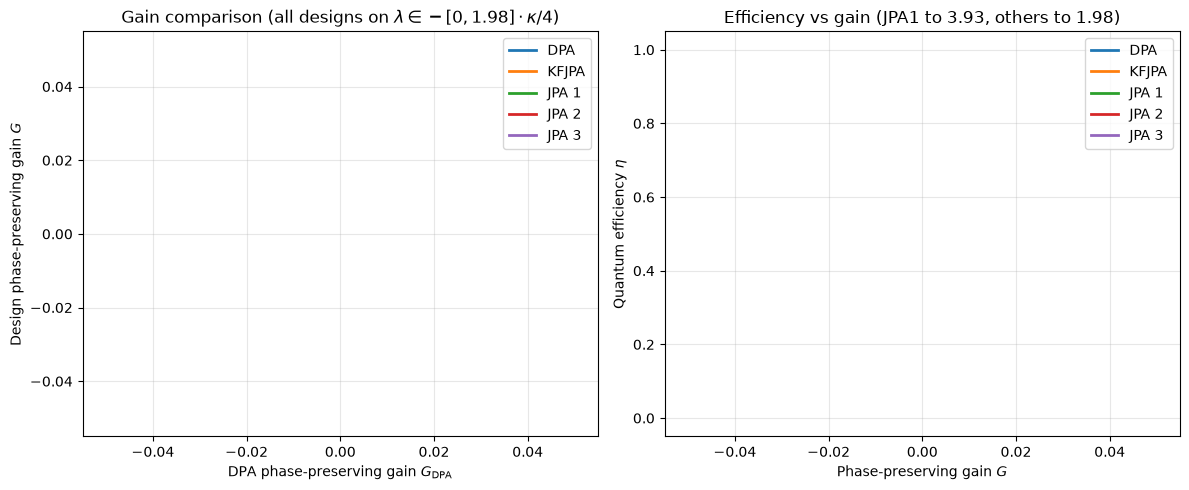

In [24]:
fig, axes, data = plot_gain_and_efficiency_mixed_spans(
    Delta,
    kappa,
    0.0,
    drive,
    10,
    theta,
    phi,
    jpa_param_sets=[
        dict(F_JPA=np.pi/4, EC_J=85e5 * 2*np.pi, EJ=1900e9 * 2*np.pi),  # JPA1 (extended)
        dict(F_JPA=np.pi/4, EC_J=85e4 * 2*np.pi, EJ=2000e9 * 2*np.pi),
        dict(F_JPA=np.pi/4, EC_J=5*85e5 * 2*np.pi, EJ=2000e9 * 2*np.pi),
    ],
)
plt.show()

--------------

In [ ]:
def _solve_two_probes_and_get_g(H0, a, kappa, gamma, drive, phi, c_ops):
    """
    Solve steady-state twice:
      probe1: epsilon
      probe2: i*epsilon
    Return g, G, and epsilon for the first probe.
    NOTE: gamma is ONLY used through c_ops (i.e., kappa+gamma in collapse).
    """
    def solve_for_epsilon(eps):
        a_in = 1j * eps / np.sqrt(kappa)  # keep kappa here (NOT kappa+gamma)
        H_probe = eps * a.dag() + np.conj(eps) * a
        rho_ss = qt.steadystate(H0 + H_probe, c_ops)
        a_exp = qt.expect(a, rho_ss)
        a_out = np.sqrt(kappa) * a_exp + a_in  # keep kappa here (NOT kappa+gamma)
        return a_out, a_in

    eps1 = drive * kappa * np.exp(-1j * phi)
    eps2 = drive * kappa * 1j * np.exp(-1j * phi)

    a_out1, a_in1 = solve_for_epsilon(eps1)
    a_out2, a_in2 = solve_for_epsilon(eps2)

    g = _gain_matrix_from_two_probes(a_out1, a_in1, a_out2, a_in2)
    G = _phase_preserving_gain_from_g(g)
    return g, G, eps1

In [ ]:
def parametric_metrics(
    kind,
    Delta, kappa, gamma, lam, drive, n_levels, theta, phi,
    Kerr=0.0, ratio=0.0
):
    """
    kind: "DPA", "JPA", "KFJPA"

    gamma: extra-noise rate. It is added to kappa ONLY in c_ops, nowhere else.

    Returns: (g_matrix, Gain_phase_preserving, F_norm, eta)
    """
    a = qt.destroy(n_levels)

    # ONLY place gamma enters:
    kappa_eff = kappa + gamma
    c_ops = [np.sqrt(kappa_eff) * a]

    # Degenerate Parametric Amplifier (DPA) Hamiltonian
    H_DPA = (Delta * a.dag() * a
             + (lam*np.exp(-1j*theta)/2) * a.dag()*a.dag()
             + np.conj(lam*np.exp(-1j*theta))/2 * a*a)

    # Add nonlinear terms depending on amplifier type
    H_nl = 0
    if kind.upper() == "DPA":
        LAM = 0.0

    elif kind.upper() == "JPA":
        LAM = -ratio * lam
        H_nl = (Kerr * a.dag()*a.dag()*a*a
                + LAM * (a.dag()*a.dag()*a.dag()*a + a.dag()*a*a*a))

    elif kind.upper() == "KFJPA":
        LAM = -ratio * lam
        H_nl = (LAM * (a.dag()*a.dag()*a.dag()*a + a.dag()*a*a*a))

    else:
        raise ValueError("kind must be one of: 'DPA', 'JPA', 'KFJPA'")

    H0 = H_DPA + H_nl

    # Gain matrix + phase-preserving gain from two steady-state solves
    g, G, epsilon = _solve_two_probes_and_get_g(H0, a, kappa, gamma, drive, phi, c_ops)

    # Added noise normalization
    if kind.upper() == "DPA":
        Coeff = kappa/4 + (lam**2)/kappa
    else:
        gsw = cmath.sqrt(G)
        lam_DPA = 1j * kappa * cmath.sqrt(-1 + gsw) / cmath.sqrt(-4 - 4*gsw)
        Coeff = kappa/4 + (np.abs(lam_DPA)**2)/kappa

    # Noise operator ain_dag
    base = ((-1j*Delta + kappa/2)*a.dag()
            - 1j*np.conj(lam*np.exp(-1j*theta))*a)/np.sqrt(kappa) \
           - 1j*np.conj(epsilon)/np.sqrt(kappa)

    if kind.upper() == "DPA":
        ain_dag = base

    elif kind.upper() == "JPA":
        ain_dag = base \
            - 1j*2*Kerr*a.dag()*a.dag()*a/np.sqrt(kappa) \
            - 1j*LAM*(a.dag()*a.dag()*a.dag() + 3*a.dag()*a*a)/np.sqrt(kappa)

    elif kind.upper() == "KFJPA":
        ain_dag = base \
            + 1j*LAM*(a.dag()*a.dag()*a.dag() + 3*a.dag()*a*a)/np.sqrt(kappa)

    var_aindag = _vacuum_variance(ain_dag, n_levels)

    F = (G - 1) * var_aindag / G
    F_norm = F / Coeff
    eta = 1 / (1 + 2*F_norm)
    G = 10 * np.log10(G)

    return g, G, F_norm, eta

In [ ]:
def Gain_get_DPA(Delta, kappa, gamma, lam, drive, n_levels, theta, phi):
    return parametric_metrics("DPA", Delta, kappa, gamma, lam, drive, n_levels, theta, phi)

def Gain_get_JPA(Delta, kappa, gamma, lam, Kerr, drive, n_levels, theta, phi, ratio):
    return parametric_metrics("JPA", Delta, kappa, gamma, lam, drive, n_levels, theta, phi, Kerr=Kerr, ratio=ratio)

def Gain_get_KFJPA(Delta, kappa, gamma, lam, drive, n_levels, theta, phi, ratio):
    return parametric_metrics("KFJPA", Delta, kappa, gamma, lam, drive, n_levels, theta, phi, Kerr=0.0, ratio=ratio)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Assumes you already defined:
#  - Gain_get_DPA(Delta, kappa, gamma, lam, drive, n_levels, theta, phi)
#  - Gain_get_JPA(Delta, kappa, gamma, lam, Kerr, drive, n_levels, theta, phi, ratio)
#  - Gain_get_KFJPA(Delta, kappa, gamma, lam, drive, n_levels, theta, phi, ratio)
#  - jpa_params(...) and kfjpa_params(...)

# -----------------------------
# Sweep + plotting utilities
# -----------------------------
def _sweep_lams(kappa, span_factor, npts):
    # lam array you requested: -linspace(0, span_factor) * kappa/4
    return -np.linspace(0.0, span_factor, npts) * (kappa / 4.0)

def _safe_real(x):
    return np.real_if_close(x)

def sweep_design(design_name, lams, fn_eval):
    """
    fn_eval(lam) -> (g_matrix, G, F_norm, eta)
    Returns dict with arrays.
    """
    Gs, etas = [], []
    for lam in lams:
        try:
            _, G, _, eta = fn_eval(lam)
            Gs.append(_safe_real(G))
            etas.append(_safe_real(eta))
        except Exception:
            # keep array lengths consistent; mark failures as NaN
            Gs.append(np.nan)
            etas.append(np.nan)

    return {
        "name": design_name,
        "lam": np.array(lams, dtype=float),
        "G": np.array(Gs, dtype=float),
        "eta": np.array(etas, dtype=float),
    }

def mask_finite(*arrays):
    m = np.ones_like(arrays[0], dtype=bool)
    for a in arrays:
        m &= np.isfinite(a)
    return m

# -----------------------------
# Main routine: produce both plots
# -----------------------------
def make_gain_and_eta_plots(
    # common sim params
    Delta, kappa, gamma, drive, n_levels, theta, phi,

    # sweep control
    npts_gain=30,
    npts_eta=30,

    # DPA reference sweep span for each plot
    span_gain=1.98,
    span_eta=3.93,

    # three JPAs parameter sets (each element overrides defaults to jpa_params)
    jpa_param_sets=None,

    # KFJPA params override
    kfjpa_EC=48e5 * 2*np.pi,
    kfjpa_EL=1650e9 * 2*np.pi,

    # plotting
    figsize=(12, 5),
):
    if jpa_param_sets is None:
        # Provide three example sets; edit as needed.
        jpa_param_sets = [
            dict(F_JPA=np.pi/4, EC_J=85e5*2*np.pi, EJ=1900e9*2*np.pi),
            dict(F_JPA=np.pi/4, EC_J=85e4*2*np.pi, EJ=2000e9*2*np.pi),
            dict(F_JPA=np.pi/4, EC_J=5*85e5*2*np.pi, EJ=2000e9*2*np.pi),
        ]

    # ---- define lam sweeps you requested
    lams_gain = _sweep_lams(kappa, span_gain, npts_gain)
    lams_eta  = _sweep_lams(kappa, span_eta,  npts_eta)

    # ---- DPA reference (for x-axis of gain plot)
    dpa_gain = sweep_design(
        "DPA(ref)",
        lams_gain,
        lambda lam: Gain_get_DPA(Delta, kappa, gamma, lam, drive, n_levels, theta, phi)
    )
    dpa_eta = sweep_design(
        "DPA",
        lams_eta,
        lambda lam: Gain_get_DPA(Delta, kappa, gamma, lam, drive, n_levels, theta, phi)
    )

    # ---- KFJPA params
    STS_ratio, _phi = kfjpa_params(EC=kfjpa_EC, EL=kfjpa_EL)

    kfjpa_gain = sweep_design(
        "KFJPA",
        lams_gain,
        lambda lam: Gain_get_KFJPA(Delta, kappa, gamma, lam, drive, n_levels, theta, phi, STS_ratio)
    )
    kfjpa_eta = sweep_design(
        "KFJPA",
        lams_eta,
        lambda lam: Gain_get_KFJPA(Delta, kappa, gamma, lam, drive, n_levels, theta, phi, STS_ratio)
    )

    # ---- 3 JPAs
    jpa_gain_curves = []
    jpa_eta_curves  = []
    for i, p in enumerate(jpa_param_sets, start=1):
        ratio, Kerr, _ = jpa_params(**p)
        name = f"JPA {i}"

        jpa_gain_curves.append(
            sweep_design(
                name,
                lams_gain,
                lambda lam, ratio=ratio, Kerr=Kerr: Gain_get_JPA(
                    Delta, kappa, gamma, lam, Kerr, drive, n_levels, theta, phi, ratio
                )
            )
        )
        jpa_eta_curves.append(
            sweep_design(
                name,
                lams_eta,
                lambda lam, ratio=ratio, Kerr=Kerr: Gain_get_JPA(
                    Delta, kappa, gamma, lam, Kerr, drive, n_levels, theta, phi, ratio
                )
            )
        )

    # -----------------------------
    # Plot 1: G_design vs G_DPA  (gain sweep)
    # x-axis: DPA gain only; y-axis: design gain
    # -----------------------------
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    x = dpa_gain["G"]
    for curve in [kfjpa_gain] + jpa_gain_curves + [dpa_gain]:
        y = curve["G"]
        m = mask_finite(x, y)
        ax1.plot(x[m], y[m], lw=2, label=curve["name"] if curve["name"] != "DPA(ref)" else "DPA")

    ax1.set_xlabel("DPA phase-preserving gain $G_{\\mathrm{DPA}}$")
    ax1.set_ylabel("Design phase-preserving gain $G$")
    ax1.set_title("Gain comparison (sweep $\\lambda$ up to 1.98·$\\kappa/4$)")
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # -----------------------------
    # Plot 2: eta vs G (eta sweep)
    # x-axis: design G; y-axis: design eta
    # -----------------------------
    all_eta_curves = [dpa_eta, kfjpa_eta] + jpa_eta_curves
    for curve in all_eta_curves:
        x2, y2 = curve["G"], curve["eta"]
        m = mask_finite(x2, y2)
        # Optional: sort by G for nicer lines
        order = np.argsort(x2[m])
        ax2.plot(x2[m][order], y2[m][order], lw=2, label=curve["name"])

    ax2.set_xlabel("Phase-preserving gain $G$")
    ax2.set_ylabel("Quantum efficiency $\\eta$")
    ax2.set_title("Efficiency vs gain (sweep $\\lambda$ up to 3.93·$\\kappa/4$)")
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(0.0, 25)
    ax2.set_ylim(-0.05, 1.05)
    ax2.legend()

    plt.tight_layout()
    return fig, (ax1, ax2), {
        "dpa_gain": dpa_gain,
        "dpa_eta": dpa_eta,
        "kfjpa_gain": kfjpa_gain,
        "kfjpa_eta": kfjpa_eta,
        "jpa_gain": jpa_gain_curves,
        "jpa_eta": jpa_eta_curves,
    }




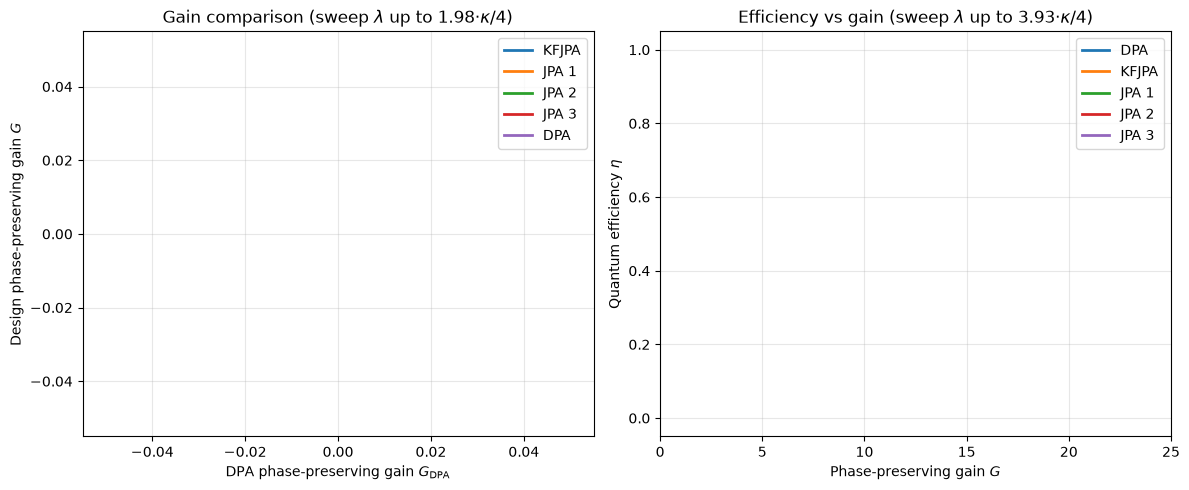

In [26]:
fig, axes, data = make_gain_and_eta_plots(
    Delta,
    kappa,
    0.0,
    drive,
    120,
    theta,
    phi,
    jpa_param_sets=[
        dict(F_JPA=np.pi/4, EC_J=85e5*2*np.pi, EJ=1900e9*2*np.pi),
            dict(F_JPA=np.pi/4, EC_J=85e4*2*np.pi, EJ=2000e9*2*np.pi),
            dict(F_JPA=np.pi/4, EC_J=5*85e5*2*np.pi, EJ=2000e9*2*np.pi),
    ],
)
plt.show()